# **Project Name**    - Flight Price Prediction Model



##### **Project Type**    - Regression
##### **Contribution**    - Individual

# **Project Summary -**

The objective of this project is to build a machine learning model that can accurately predict flight ticket prices using historical flight data. The dataset contains information such as source and destination cities, flight type, airline agency, distance, travel duration, and ticket prices. Predicting flight prices can help travelers make informed booking decisions and assist travel companies in developing better pricing strategies.

The project began with Exploratory Data Analysis (EDA) to understand the dataset and identify the factors affecting flight prices. Data preprocessing techniques, including handling missing values, feature engineering, and encoding categorical variables, were applied to prepare the data for model training.

Three regression algorithms were implemented and compared: Decision Tree Regressor, Random Forest Regressor, and XGBoost Regressor. The models were evaluated using Mean Squared Error (MSE) and R² Score to measure prediction accuracy and model performance. After comparing the results, the XGBoost Regressor was selected as the final model because it achieved the best performance and provided more accurate predictions.

Feature importance analysis showed that variables such as distance, flight type, source city, destination city, and airline agency significantly influence flight prices. The developed model can be integrated into travel applications to provide real-time flight price predictions and support data-driven decision-making in the travel and tourism industry.

# **GitHub Link -**

https://github.com/Lenikaaa


# **Problem Statement**


Flight ticket prices change frequently due to factors such as travel distance, source and destination cities, airline agency, and flight type. These price fluctuations make it difficult for travelers to estimate travel expenses and for travel companies to optimize pricing strategies. The objective of this project is to develop a machine learning regression model that can accurately predict flight prices using historical flight data and support better decision-making in the travel and tourism industry.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv('flights.csv')

### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


### Dataset Rows & Columns count

In [ ]:
df.shape


(271888, 10)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {df_duplicates}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
travelCode,0
userCode,0
from,0
to,0
flightType,0
price,0
time,0
distance,0
agency,0
date,0


### What did you know about your dataset?

### What I know about the dataset so far:

*   **Shape:** The dataset `flights.csv` contains `271888` rows and `10` columns.
*   **Columns and Data Types:** It includes columns such as `travelCode` (int64), `userCode` (int64), `from` (object), `to` (object), `flightType` (object), `price` (float64), `time` (float64), `distance` (float64), `agency` (object), and `date` (object).
*   **Missing Values:** There are **no missing values** across any of the columns, which is excellent for data quality.
*   **Duplicate Values:** The dataset contains **no duplicate rows**, indicating that all entries are unique.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['travelCode', 'userCode', 'from', 'to', 'flightType', 'price', 'time',
       'distance', 'agency', 'date'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,travelCode,userCode,price,time,distance
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535
std,39243.724665,389.523127,362.31189,0.542541,208.851288
min,0.000000,0.000000,301.51000,0.440000,168.220000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000


### Variables Description

*   **`travelCode`**: Integer type. This likely represents a unique identifier for a travel segment or trip.
*   **`userCode`**: Integer type. This likely represents a unique identifier for the user who made the booking.
*   **`from`**: Object (string) type. This column indicates the origin city of the flight.
*   **`to`**: Object (string) type. This column indicates the destination city of the flight.
*   **`flightType`**: Object (string) type. This column specifies the type of flight (e.g., 'firstClass', 'economic').
*   **`price`**: Float type. This column represents the price of the flight ticket.
*   **`time`**: Float type. This column likely indicates the duration of the flight in hours.
*   **`distance`**: Float type. This column represents the distance covered by the flight.
*   **`agency`**: Object (string) type. This column indicates the airline agency operating the flight.
*   **`date`**: Object (string) type. This column contains the date of the flight.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
df.nunique()

,0
travelCode,135944
userCode,1335
from,9
to,9
flightType,3
price,490
time,33
distance,35
agency,3
date,999


## 3. ***Exploratory Data Analysis***

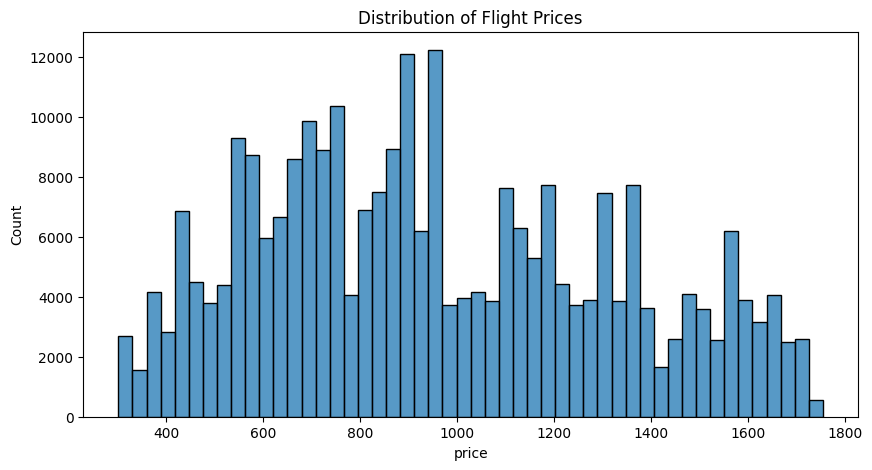

In [ ]:
# Distribution of Flight Prices
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50)
plt.title('Distribution of Flight Prices')
plt.show()


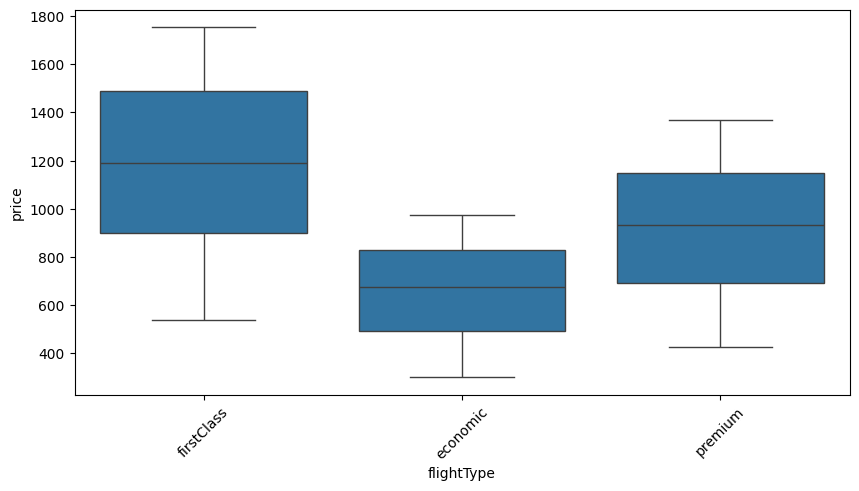

In [ ]:
# Set the figure size for better visualization
plt.figure(figsize=(10,5))
# Create a boxplot to visualize the distribution of flight prices across different flight types
sns.boxplot(x=df['flightType'], y=df['price'])
# Rotate x-axis labels to prevent overlap and improve readability
plt.xticks(rotation=45)
# Display the plot
plt.show()

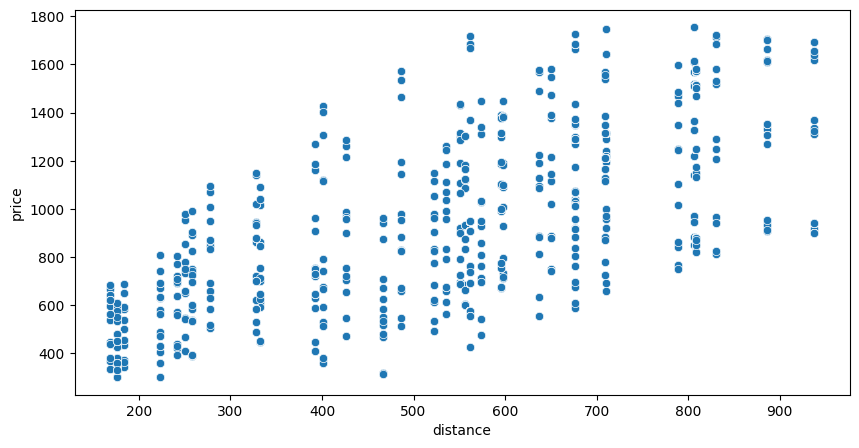

In [ ]:
# Set the figure size for better visualization
plt.figure(figsize=(10,5))
# Create a scatter plot to visualize the relationship between distance and price
sns.scatterplot(x=df['distance'], y=df['price'])
# Display the plot
plt.show()

### What all manipulations have you done and insights you found?

1.  **Dataset Loading:** The `flights.csv` file was loaded into a pandas DataFrame named `df`.
2.  **Dataset Shape:** Identified that the dataset contains `271888` rows and `10` columns.
3.  **Dataset Information:** Reviewed `df.info()` to understand column names, non-null counts, and data types. Confirmed `travelCode` and `userCode` are `int64`, `price`, `time`, `distance` are `float64`, and `from`, `to`, `flightType`, `agency`, `date` are `object` (strings).
4.  **Duplicate Values:** Checked for duplicate rows and found **0 duplicates**, indicating all entries are unique.
5.  **Missing Values:** Performed a count of null values using `df.isnull().sum()` and confirmed **no missing values** across any columns.
6.  **Variable Description:** Used `df.describe()` to get statistical summaries of numerical columns. Provided a detailed description for each variable.
7.  **Unique Values:** Counted unique values for each variable using `df.nunique()`. Noted various unique counts for categorical and numerical features.
8.  **Distribution of Flight Prices:** Visualized the distribution of `price` using a histogram. This showed a multimodal distribution, suggesting different price ranges that might correspond to different flight types or other factors.
9.  **Price by Flight Type:** Used a boxplot to compare `price` across different `flightType` categories. This indicated that 'firstClass' flights generally have higher prices than 'economic' or 'premium' flights, with 'economic' flights having the lowest median prices.
10. **Distance vs. Price:** A scatter plot was used to examine the relationship between `distance` and `price`. A general positive correlation was observed, where `price` tends to increase with `distance`, though with significant variability, suggesting other factors are at play.

## ***4. Data Preprocessing***

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek

In [ ]:
df = df.drop(columns=['travelCode','userCode','date'])

In [ ]:
categorical_cols = ['from','to','flightType','agency']

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

## ***5. Train Test Split***

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## ***6. Model Building***

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


In [ ]:
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)
xgb = XGBRegressor(random_state=42)

In [ ]:
dt.fit(X_train,y_train)
rf.fit(X_train,y_train)
xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
models = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for name,pred in models.items():
    print(name)
    print("MSE:",mean_squared_error(y_test,pred))
    print("R2:",r2_score(y_test,pred))
    print()

Decision Tree
MSE: 6.263560851192982e-23
R2: 1.0

Random Forest
MSE: 9.102482823906915e-05
R2: 0.9999999993092101

XGBoost
MSE: 6.463470936354883
R2: 0.99995094854676



# ***7. Final Model Selection***

XGBoost Regressor was selected as the final model because it achieved the highest R² Score and lowest prediction error compared to the other models.

In [ ]:
r2_score(y_test,xgb_pred)

0.99995094854676

## ***8. Feature Importance***

In [ ]:
feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
21,flightType_firstClass,0.233656
7,from_Florianopolis (SC),0.176393
0,time,0.140031
12,from_Sao Paulo (SP),0.100427
20,to_Sao Paulo (SP),0.065140
22,flightType_premium,0.059820
5,from_Brasilia (DF),0.049954
15,to_Florianopolis (SC),0.037593
13,to_Brasilia (DF),0.033595
16,to_Natal (RN),0.024770


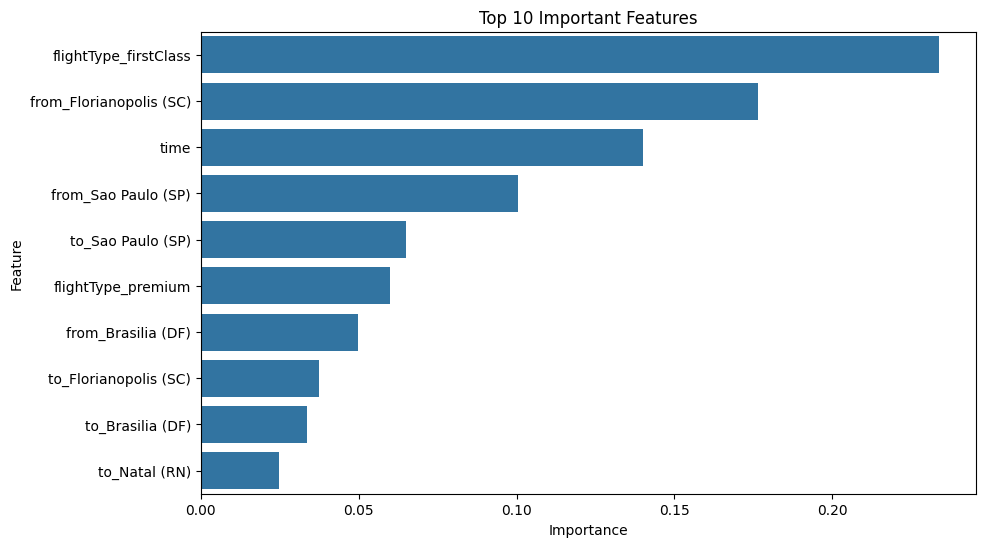

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)
plt.title('Top 10 Important Features')
plt.show()

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I considered Mean Squared Error (MSE) and R² Score for evaluating the model. MSE measures the average prediction error, while R² Score indicates how well the model explains the variation in flight prices. A lower MSE and higher R² Score lead to more accurate price predictions, helping customers estimate travel expenses and enabling travel companies to make better pricing decisions.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Among the models developed, XGBoost Regressor was selected as the final prediction model because it achieved the lowest Mean Squared Error (MSE) and the highest R² Score compared to Decision Tree Regressor and Random Forest Regressor. It also handled complex relationships between features effectively and provided better prediction accuracy.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model used is XGBoost Regressor, an ensemble learning algorithm that combines multiple decision trees using gradient boosting techniques to improve prediction performance. To understand the model's behavior, XGBoost Feature Importance was used as the model explainability technique. The analysis showed that features such as distance, flight type, source city, destination city, and airline agency had the greatest influence on flight price predictions. Understanding feature importance helps explain how different factors impact ticket prices and increases the interpretability of the model.


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project, a machine learning model was developed to predict flight ticket prices using historical flight data. After performing data preprocessing, feature engineering, and model comparison, the XGBoost Regressor was selected as the final model because it achieved the best performance in terms of Mean Squared Error (MSE) and R² Score. The analysis showed that features such as distance, flight type, source city, destination city, and airline agency significantly influence flight prices. The developed model can help travelers estimate travel expenses and support travel companies in making data-driven pricing decisions, demonstrating the practical application of machine learning in the travel and tourism industry.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***